已连接到 Battery Analysis (.venv) (Python 3.14.7)

图片已保存到：D:\Desktop\BatteryAnalysis\group4_capacity.png


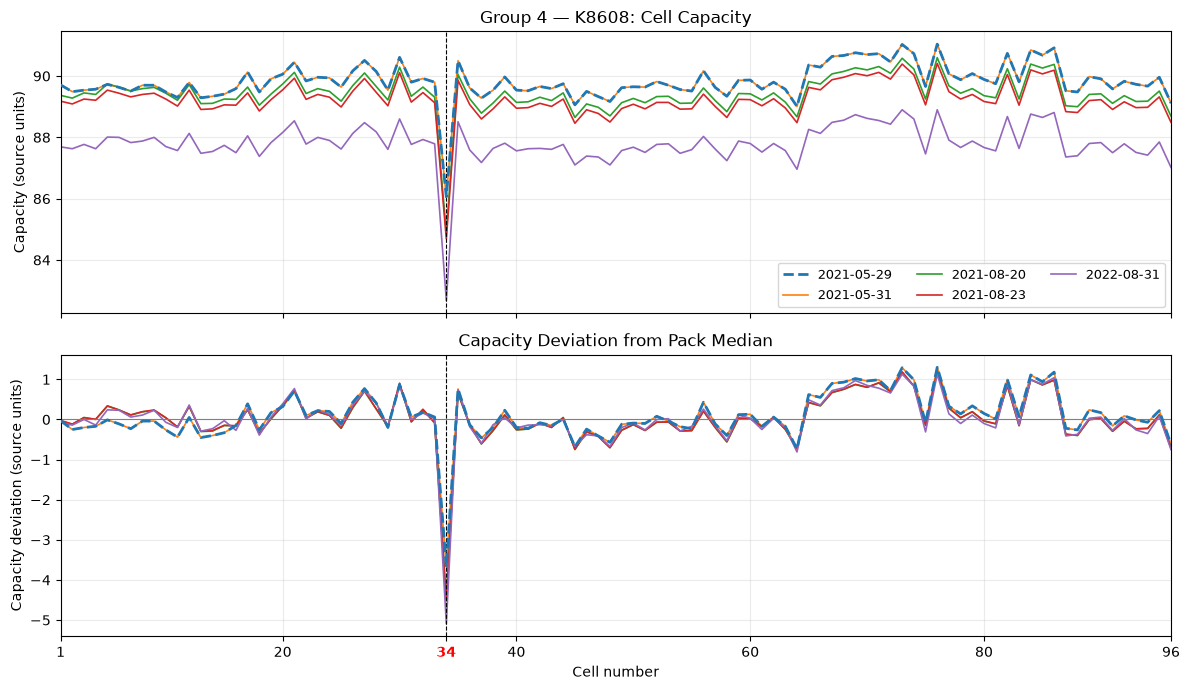

In [ ]:
#第4组全组的capacity
# 读取第 4 组数据
import pandas as pd
import matplotlib.pyplot as plt

path = r"D:\Desktop\BatteryAnalysis\UU_dataset_25w37.xlsx"
df = pd.read_excel(path, sheet_name="UU_dataset_24w33")
df = df.loc[df["Dataset"] == 4].copy()
df["Readout"] = pd.to_datetime(df["Readout"], format="mixed")
df = df.sort_values("Readout")

# 提取容量列，按电芯编号排序
cols = sorted(
    [c for c in df.columns if c.startswith("C_")],
    key=lambda c: int(c.split("_")[1])
)
cells = [int(c.split("_")[1]) for c in cols]
capacity = df[cols].apply(pd.to_numeric, errors="raise")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i, (date, (_, c)) in enumerate(
    zip(df["Readout"], capacity.iterrows())
):
    label = date.strftime("%Y-%m-%d")

    # 第一条蓝线使用虚线，并显示在其他曲线上方
    style = {
        "linestyle": "--" if i == 0 else "-",
        "linewidth": 2.0 if i == 0 else 1.2,
        "zorder": 5 if i == 0 else 2
    }

    axes[0].plot(cells, c, label=label, **style)
    axes[1].plot(cells, c - c.median(), **style)

axes[0].set_title("Group 4 — K8608: Cell Capacity")
axes[0].set_ylabel("Capacity (source units)")
axes[0].legend(ncol=3, fontsize=9)

axes[1].set_title("Capacity Deviation from Pack Median")
axes[1].set_ylabel("Capacity deviation (source units)")
axes[1].set_xlabel("Cell number")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_xticks([1, 20, 34, 40, 60, 80, 96])

for ax in axes:
    ax.axvline(34, color="black", linestyle="--", linewidth=0.8)
    ax.grid(alpha=0.25)
    ax.set_xlim(1, 96)

for tick in axes[1].get_xticklabels():
    if tick.get_text() == "34":
        tick.set_color("red")
        tick.set_fontweight("bold")

# 图片保存在 Excel 所在文件夹
from pathlib import Path
output = Path(path).parent / "group4_capacity.png"
plt.tight_layout()
plt.savefig(output, dpi=300)
print(f"图片已保存到：{output}")
plt.show()

图片已保存到：D:\Desktop\BatteryAnalysis\group4_soc_raw.png


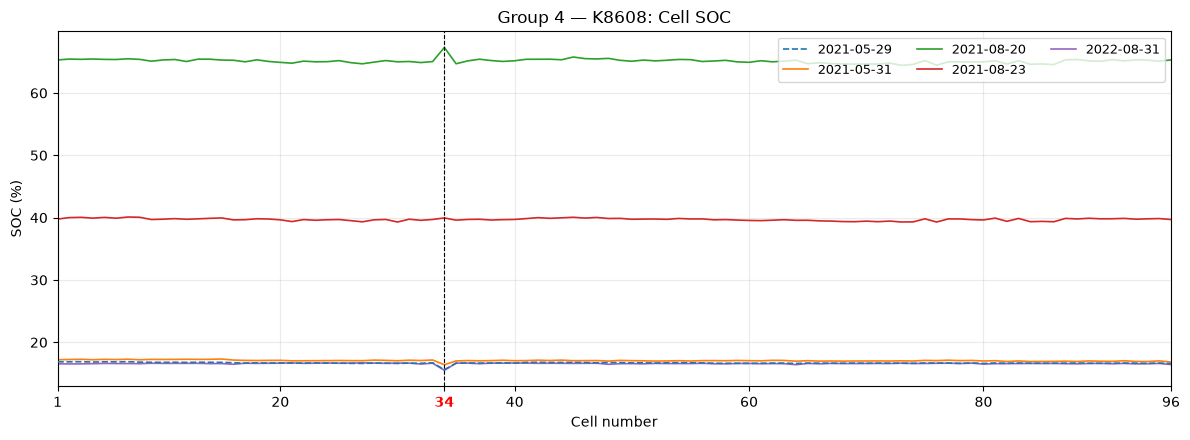

In [ ]:
# # %% 第4组：SOC原始值
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

path = Path(r"D:\Desktop\BatteryAnalysis\UU_dataset_25w37.xlsx")
df = pd.read_excel(path, sheet_name="UU_dataset_24w33")
df = df.loc[df["Dataset"] == 4].copy()
df["Readout"] = pd.to_datetime(df["Readout"], format="mixed")
df = df.sort_values("Readout")

cols = sorted(
    [c for c in df.columns if c.startswith("S_")],
    key=lambda c: int(c.split("_")[1])
)
cells = [int(c.split("_")[1]) for c in cols]
soc = df[cols].apply(pd.to_numeric, errors="raise")

fig, ax = plt.subplots(figsize=(12, 4.5))

for i, (date, (_, s)) in enumerate(
    zip(df["Readout"], soc.iterrows())
):
    ax.plot(
        cells, s,
        label=date.strftime("%Y-%m-%d"),
        linestyle="--" if i == 0 else "-",
        linewidth=1.2,
        zorder=5 if i == 0 else 2
    )

ax.set_title("Group 4 — K8608: Cell SOC")
ax.set_xlabel("Cell number")
ax.set_ylabel("SOC (%)")
ax.set_xlim(1, 96)
ax.set_xticks([1, 20, 34, 40, 60, 80, 96])
ax.axvline(34, color="black", linestyle="--", linewidth=0.8)
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)

for tick in ax.get_xticklabels():
    if tick.get_text() == "34":
        tick.set_color("red")
        tick.set_fontweight("bold")

output = path.parent / "group4_soc_raw.png"
plt.tight_layout()
fig.savefig(output, dpi=300)
print(f"图片已保存到：{output}")
plt.show()

图片已保存到：D:\Desktop\BatteryAnalysis\group4_capacity_raw.png


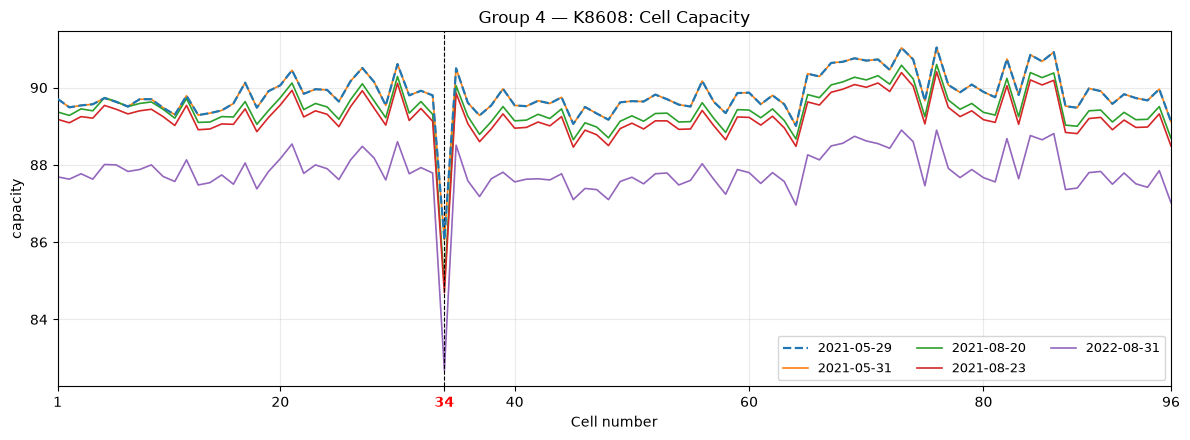

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

path = Path(r"D:\Desktop\BatteryAnalysis\UU_dataset_25w37.xlsx")
df = pd.read_excel(path, sheet_name="UU_dataset_24w33")
df = df.loc[df["Dataset"] == 4].copy()
df["Readout"] = pd.to_datetime(df["Readout"], format="mixed")
df = df.sort_values("Readout")

cols = sorted(
    [c for c in df.columns if c.startswith("C_")],
    key=lambda c: int(c.split("_")[1])
)
cells = [int(c.split("_")[1]) for c in cols]
capacity = df[cols].apply(pd.to_numeric, errors="raise")

fig, ax = plt.subplots(figsize=(12, 4.5))

for i, (date, (_, c)) in enumerate(
    zip(df["Readout"], capacity.iterrows())
):
    ax.plot(
        cells, c,
        label=date.strftime("%Y-%m-%d"),
        linestyle="--" if i == 0 else "-",
        linewidth=1.6 if i == 0 else 1.2,
        zorder=5 if i == 0 else 2
    )

ax.set_title("Group 4 — K8608: Cell Capacity")
ax.set_xlabel("Cell number")
ax.set_ylabel("capacity")
ax.set_xlim(1, 96)
ax.set_xticks([1, 20, 34, 40, 60, 80, 96])
ax.axvline(34, color="black", linestyle="--", linewidth=0.8)
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)

for tick in ax.get_xticklabels():
    if tick.get_text() == "34":
        tick.set_color("red")
        tick.set_fontweight("bold")

output = path.parent / "group4_capacity_raw.png"
plt.tight_layout()
fig.savefig(output, dpi=300)
print(f"图片已保存到：{output}")
plt.show()

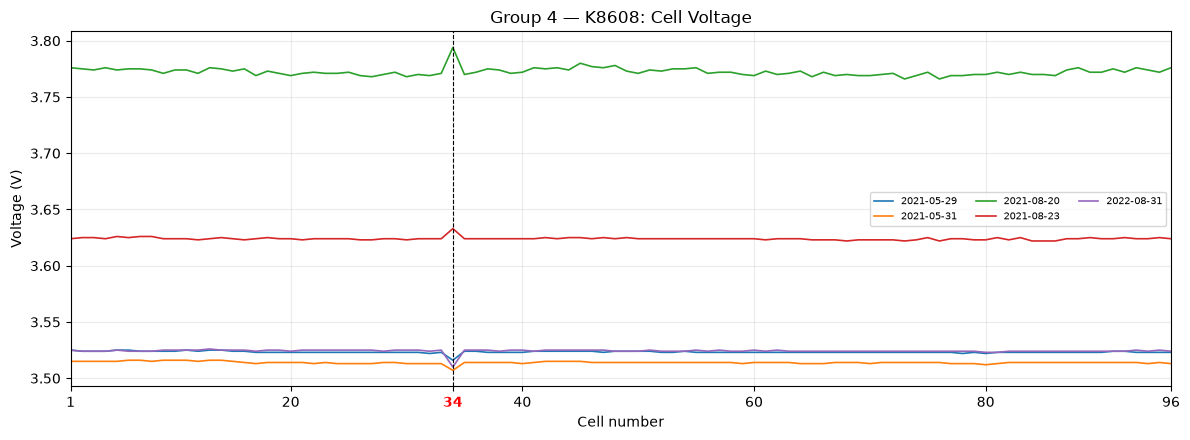

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"D:\Desktop\BatteryAnalysis\UU_dataset_25w37.xlsx"
df = pd.read_excel(path, sheet_name="UU_dataset_24w33")
df = df.loc[df["Dataset"] == 4].copy()
df["Readout"] = pd.to_datetime(df["Readout"], format="mixed")
df = df.sort_values("Readout")

cols = sorted(
    [c for c in df.columns if c.startswith("V_")],
    key=lambda c: int(c.split("_")[1])
)
cells = [int(c.split("_")[1]) for c in cols]
voltage = df[cols].apply(pd.to_numeric, errors="raise")

fig, ax = plt.subplots(figsize=(12, 4.5))

for date, (_, v) in zip(df["Readout"], voltage.iterrows()):
    label = date.strftime("%Y-%m-%d")
    ax.plot(cells, v, linewidth=1.2, label=label)

ax.set_title("Group 4 — K8608: Cell Voltage")
ax.set_ylabel("Voltage (V)")
ax.set_xlabel("Cell number")
ax.legend(ncol=3, fontsize=7)

ax.axvline(34, color="black", linestyle="--", linewidth=0.8)
ax.grid(alpha=0.25)
ax.set_xlim(1, 96)
ax.set_xticks([1, 20, 34, 40, 60, 80, 96])

for tick in ax.get_xticklabels():
    if tick.get_text() == "34":
        tick.set_color("red")
        tick.set_fontweight("bold")

plt.tight_layout()
plt.savefig("group4_voltage_raw.png", dpi=300)
plt.show()

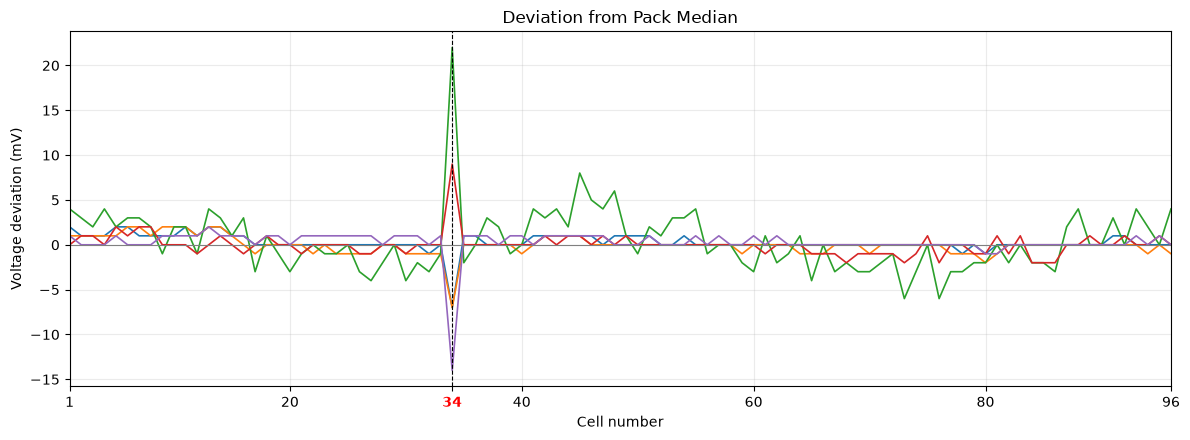

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = r"D:\Desktop\BatteryAnalysis\UU_dataset_25w37.xlsx"
df = pd.read_excel(path, sheet_name="UU_dataset_24w33")
df = df.loc[df["Dataset"] == 4].copy()
df["Readout"] = pd.to_datetime(df["Readout"], format="mixed")
df = df.sort_values("Readout")

cols = sorted(
    [c for c in df.columns if c.startswith("V_")],
    key=lambda c: int(c.split("_")[1])
)
cells = [int(c.split("_")[1]) for c in cols]
voltage = df[cols].apply(pd.to_numeric, errors="raise")

fig, ax = plt.subplots(figsize=(12, 4.5))

for date, (_, v) in zip(df["Readout"], voltage.iterrows()):
    ax.plot(cells, (v - v.median()) * 1000, linewidth=1.2)

ax.set_title("Deviation from Pack Median")
ax.set_ylabel("Voltage deviation (mV)")
ax.set_xlabel("Cell number")
ax.axhline(0, color="gray", linewidth=0.8)

ax.axvline(34, color="black", linestyle="--", linewidth=0.8)
ax.grid(alpha=0.25)
ax.set_xlim(1, 96)
ax.set_xticks([1, 20, 34, 40, 60, 80, 96])

for tick in ax.get_xticklabels():
    if tick.get_text() == "34":
        tick.set_color("red")
        tick.set_fontweight("bold")

plt.tight_layout()
plt.savefig("group4_voltage_deviation.png", dpi=300)
plt.show()

图片已保存到：D:\Desktop\BatteryAnalysis\Group4_KM_Capacity.png


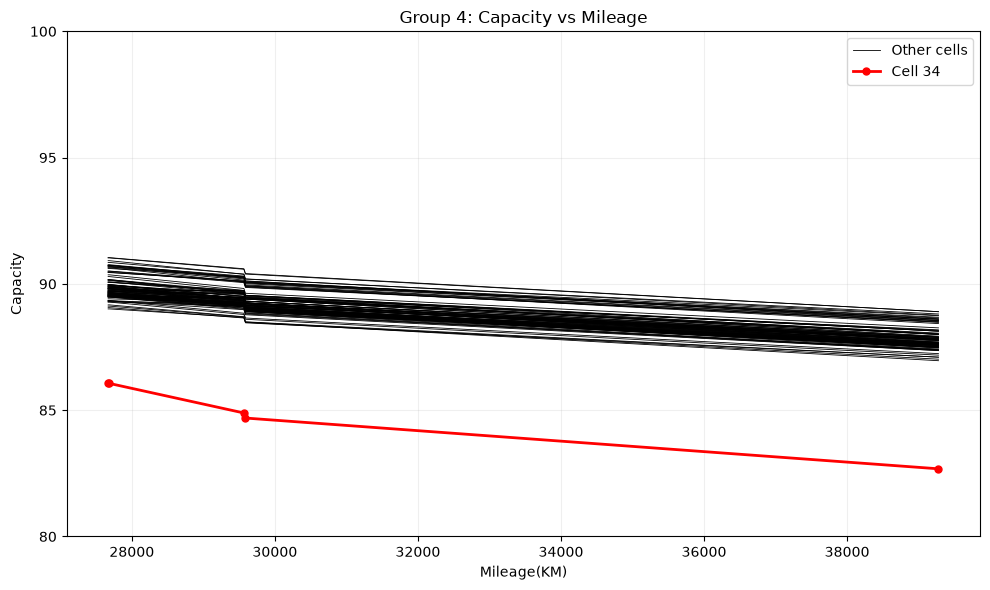

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
path = Path(r"D:\Desktop\BatteryAnalysis\Group4_KM_Capacity.xlsx")
df = pd.read_excel(path, sheet_name="Sheet1")

cols = sorted(
    [c for c in df.columns if c.startswith("C_")],
    key=lambda c: int(c.split("_")[1])
)

df[["KM"] + cols] = df[["KM"] + cols].apply(
    pd.to_numeric, errors="raise"
)
df = df.sort_values("KM")

fig, ax = plt.subplots(figsize=(10, 6))

# 其他电芯：黑色
other_cols = [c for c in cols if c != "C_34"]
for i, col in enumerate(other_cols):
    ax.plot(
        df["KM"], df[col],
        color="black",
        linewidth=0.6,
        label="Other cells" if i == 0 else None
    )

# 第34号电芯：红色
ax.plot(
    df["KM"], df["C_34"],
    color="red",
    linewidth=2,
    marker="o",
    markersize=5,
    label="Cell 34",
    zorder=10
)

ax.set_title("Group 4: Capacity vs Mileage")
ax.set_xlabel("Mileage(KM)")
ax.set_ylabel("Capacity")

ax.set_ylim(80, 100)
ax.set_yticks(range(80, 101, 5))
ax.ticklabel_format(axis="x", style="plain", useOffset=False)

ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()

output = path.with_suffix(".png")
fig.savefig(output, dpi=300)
print(f"图片已保存到：{output}")
plt.show()

图片已保存到：D:\Desktop\BatteryAnalysis\Group4_KM_Capacity.png


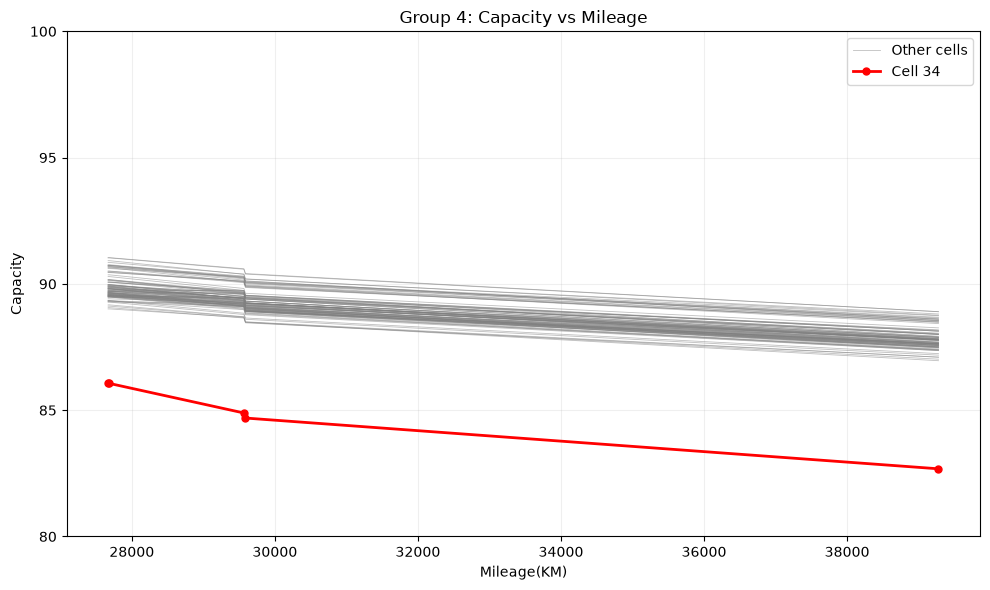

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
path = Path(r"D:\Desktop\BatteryAnalysis\Group4_KM_Capacity.xlsx")
df = pd.read_excel(path, sheet_name="Sheet1")

cols = sorted(
    [c for c in df.columns if c.startswith("C_")],
    key=lambda c: int(c.split("_")[1])
)

df[["KM"] + cols] = df[["KM"] + cols].apply(
    pd.to_numeric, errors="raise"
)
df = df.sort_values("KM")

fig, ax = plt.subplots(figsize=(10, 6))

# 其他电芯：黑色
other_cols = [c for c in cols if c != "C_34"]
for i, col in enumerate(other_cols):
    ax.plot(
        df["KM"], df[col],
        color="gray",
        alpha=0.5,
        linewidth=0.6,
        label="Other cells" if i == 0 else None
    )

# 第34号电芯：红色
ax.plot(
    df["KM"], df["C_34"],
    color="red",
    linewidth=2,
    marker="o",
    markersize=5,
    label="Cell 34",
    zorder=10
)

ax.set_title("Group 4: Capacity vs Mileage")
ax.set_xlabel("Mileage(KM)")
ax.set_ylabel("Capacity")

ax.set_ylim(80, 100)
ax.set_yticks(range(80, 101, 5))
ax.ticklabel_format(axis="x", style="plain", useOffset=False)

ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()

output = path.with_suffix(".png")
fig.savefig(output, dpi=300)
print(f"图片已保存到：{output}")
plt.show()